과제
---------
sklearn 의 breast_cancer 데이터셋

1. train, test 나누기
2. 정규화
3. 케라스 학습
4. train, test 각각 confusion matrix(heat map 포함), f1, acc
5. 1번째행 예측값

In [1]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential
from keras.layers import Dense
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family']='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

In [2]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer(as_frame=True)
cancer['frame']

x_data = cancer['data'].values
y_data = cancer['target'].values

In [3]:
x_data.shape

(569, 30)

In [4]:
y_data.shape

(569,)

train, test 나누기, 정규화

In [5]:
scaleF = StandardScaler()
x_dataN = scaleF.fit_transform( x_data)

In [6]:
x_train, x_test, y_train, y_test = train_test_split( x_dataN, y_data, test_size=0.3, stratify=y_data)

케라스 학습

In [7]:
dense = Dense(units=1, input_dim=30, activation='sigmoid')
model = Sequential([dense])
model.compile( loss='binary_crossentropy', optimizer=Adam(0.1) , metrics=['acc'] )
h = model.fit( x_train, y_train, epochs=500)

Epoch 1/500


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.8844 - loss: 0.2759  
Epoch 2/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9849 - loss: 0.0761 
Epoch 3/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9799 - loss: 0.0705 
Epoch 4/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9824 - loss: 0.0645 
Epoch 5/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9849 - loss: 0.0636 
Epoch 6/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9874 - loss: 0.0610 
Epoch 7/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - acc: 0.9874 - loss: 0.0587 
Epoch 8/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.9874 - loss: 0.0574 
Epoch 9/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9874 - loss: 0.0545 
Epoch 10/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9874 - loss: 0.0520 
Epoch 11/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9874 - loss: 0.0499 
Epoch 12/500
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc: 0.9874 - loss: 0.0496 
Epoch 13/500
13/13 ━━━━━━━━━━━━━━━━━

train, test 각각 confusion matrix(heat map 포함), f1, acc

In [15]:
y_prob_tr = model.predict(x_train).ravel()  # ravel = 1차원으로 펼치기
y_pred_tr = (y_prob_tr >= 0.5).astype(int)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


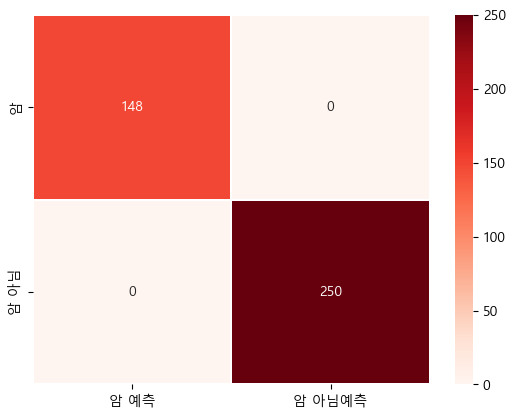

In [16]:
c = confusion_matrix(y_train, y_pred_tr)
sb.heatmap(c, annot=True, fmt='d', linewidths=0.2, cmap='Reds',
           xticklabels=['암 예측', '암 아님예측'], yticklabels=['암', '암 아님'])

plt.show()

In [17]:
y_prob_ts = model.predict(x_test).ravel()  # ravel = 1차원으로 펼치기
y_pred_ts = (y_prob_ts >= 0.5).astype(int)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


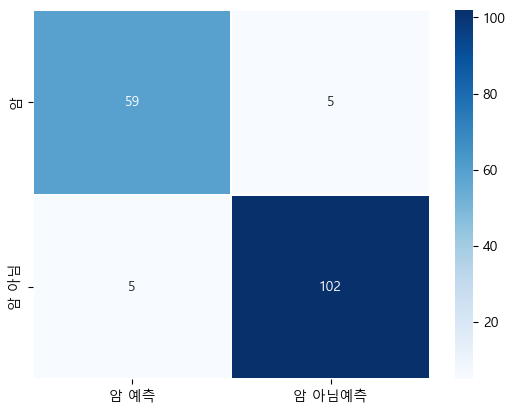

In [18]:
c = confusion_matrix(y_test, y_pred_ts)
sb.heatmap(c, annot=True, fmt='d', linewidths=0.2, cmap='Blues',
           xticklabels=['암 예측', '암 아님예측'], yticklabels=['암', '암 아님'])

plt.show()

In [19]:
print('train 정확도', accuracy_score(y_train, y_pred_tr) )
print('train f1 score', f1_score(y_train, y_pred_tr) )
print('test 정확도', accuracy_score(y_test, y_pred_ts) )
print('test f1 score', f1_score(y_test, y_pred_ts) )

train 정확도 1.0
train f1 score 1.0
test 정확도 0.9415204678362573
test f1 score 0.9532710280373832


1번째행 예측값

In [11]:
model.predict(x_dataN[[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


array([[0.]], dtype=float32)